# Complain Priority System

## About dataset
### Context
These are real-world complaints regarding financial products and services. Each complaint has been labeled with its respective product category, sentiment, and priority level to facilitate the analysis of customer feedback. This dataset offers a structured methodology for comprehending customer issues and prioritizing responses. It is especially valuable for machine learning practitioners and researchers who specialize in sentiment analysis, natural language processing, and optimizing customer service.

### Content
This dataset is an extension of an original financial dataset sourced from Kaggle. Here are the key details:

- Number of Records: 1750
- Classes: 7 product classes with 250 records each
- Attributes: Each record includes:
- Product: The financial product category
- Consumer Complaint: The text of the customer complaint
- Sentiment: Manually labeled sentiment (0 for neutral, 1 for negative)
- Priority: Manually labeled priority (0 for not urgent, 1 for urgent)

Modifications and Additions:
- Selection: Chosen 250 records per product class
- Manual Labeling: Sentiment and priority values were manually labeled based on the following criteria:
- Sentiment Values: 0 for neutral, 1 for negative (no positive values due to the nature of complaints)
- Priority Values: 0 for not urgent, 1 for urgent

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv("C:\\Users\\aishw\\Downloads\\Customer Complaints Sentiment and Priority Dataset.csv")

In [3]:
df.sample(5)

,Consumer_complaint,Product,Sentiment,Priority
350,"I am a victim of the inquiry issue, random inq...","Credit reporting, repair, or other",0,0
1078,"I am Victim of identity fraud, i recently foun...",Credit card or prepaid card,1,1
1597,Coinbase is a fraud. They state on their websi...,"Money transfer, virtual currency, or money ser...",0,1
469,I have tried to contact this company several t...,Debt collection,1,1
209,I never received a statement and by law they a...,Credit card or prepaid card,0,1


## Data Preprocessing and EDA

#### checking for null values

In [4]:
df.isnull().sum()

Consumer_complaint    0
Product               0
Sentiment             0
Priority              0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

There are no null values in the dataset.

#### checking whether the data is imbalance

In [6]:
df['Priority'].value_counts()

Priority
1    1374
0     376
Name: count, dtype: int64

In [7]:
df['Product'].value_counts()

Product
Checking or savings account or service                250
Credit card or prepaid card                           250
Credit reporting, repair, or other                    250
Debt collection                                       250
Loans                                                 250
Money transfer, virtual currency, or money service    250
Mortgage                                              250
Name: count, dtype: int64

In [8]:
df['Sentiment'].value_counts()

Sentiment
0    1295
1     455
Name: count, dtype: int64

the data is highly immbalance in terms of priority and sentiment having more not urgent and neutral cases

#### Graphical representation

In [9]:
#count plot

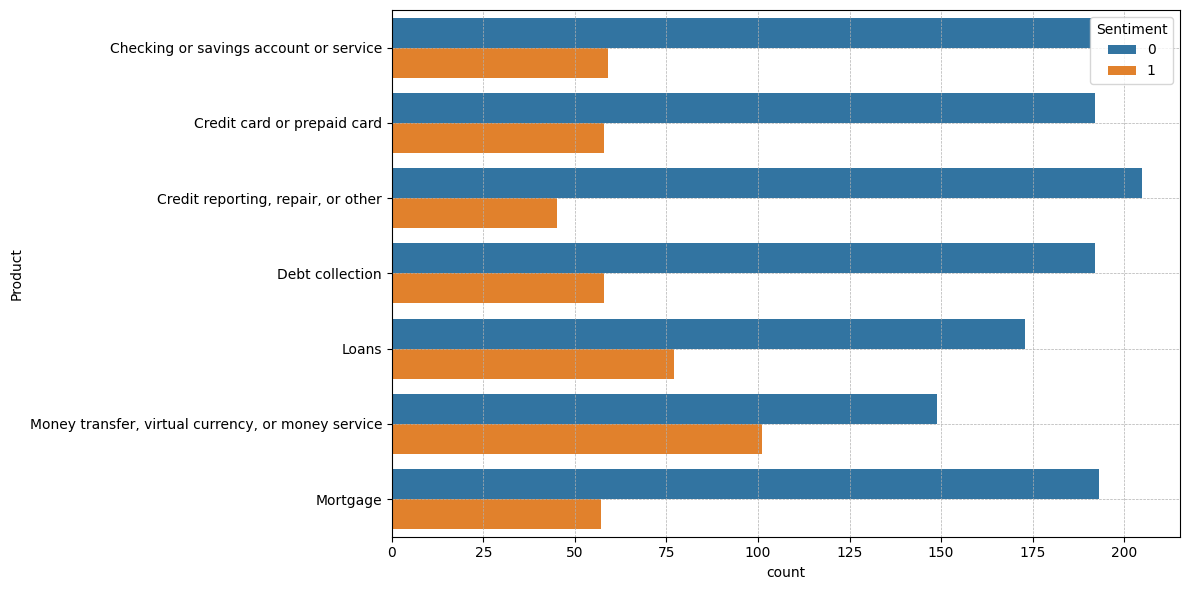

In [10]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='Product',
    hue='Sentiment',
    data=df
)

plt.grid(ls='--', lw=0.5)
plt.tight_layout()
plt.show()

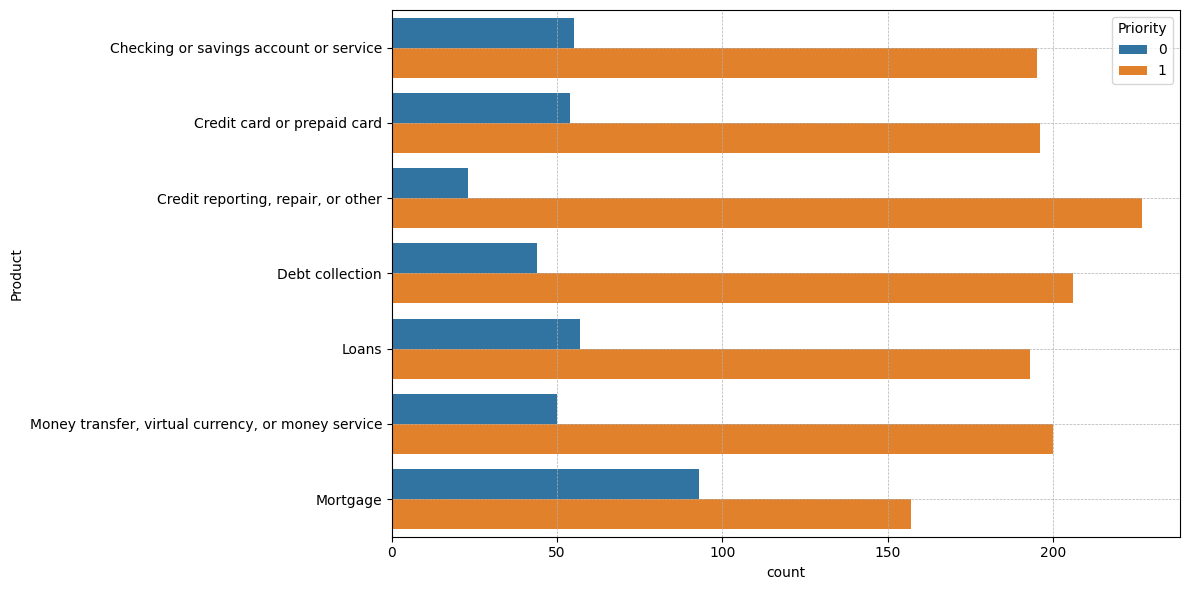

In [11]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='Product',
    hue='Priority',
    data=df
)

plt.grid(ls='--', lw=0.5)
plt.tight_layout()
plt.show()

In [12]:
#product vs priority heatmap

<Axes: xlabel='Priority', ylabel='Product'>

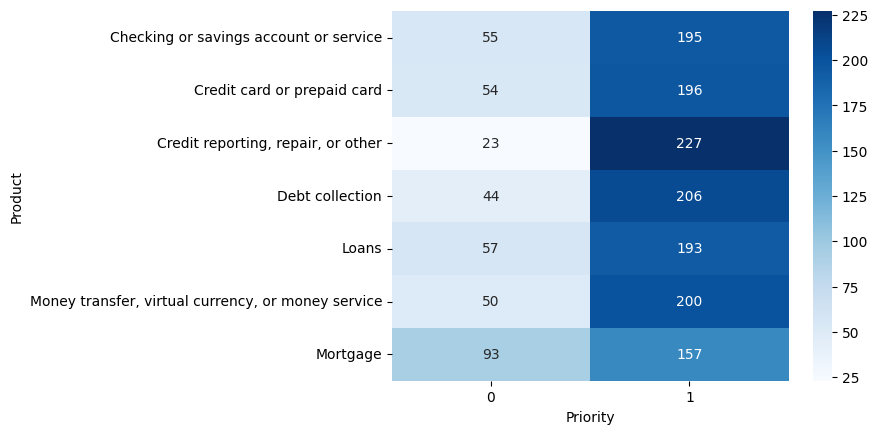

In [13]:
table = pd.crosstab(
    df['Product'],
    df['Priority']
)

sns.heatmap(
    table,
    annot=True,
    fmt='d',
    cmap='Blues'
)

As we can see the highest urgent complaints are from credit reporting, repair, or other and then we have money transfer, virtual currency, or money service.

The least no of urgent complaints are from Mortgage

<Axes: xlabel='Sentiment', ylabel='count'>

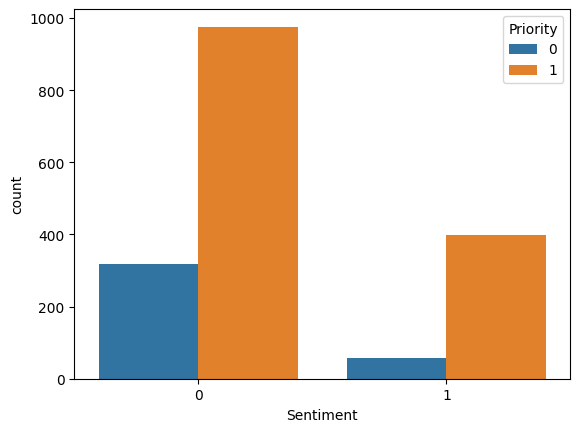

In [14]:
sns.countplot(
    x='Sentiment',
    hue='Priority',
    data=df
)

<Axes: xlabel='Priority', ylabel='Sentiment'>

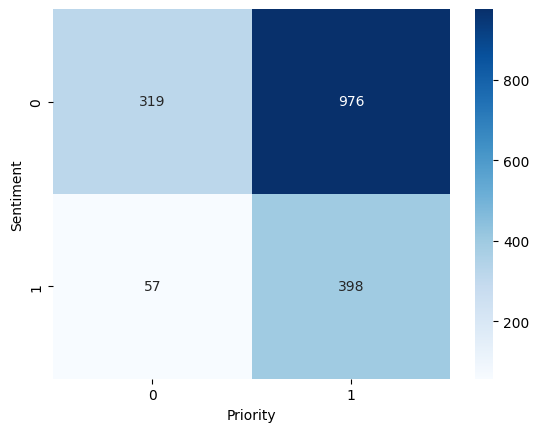

In [15]:
table = pd.crosstab(
    df['Sentiment'],
    df['Priority']
)

sns.heatmap(
    table,
    annot=True,
    fmt='d',
    cmap='Blues'
)

- Sentiment Values: 0 for neutral, 1 for negative (no positive values due to the nature of complaints)
- Priority Values: 0 for not urgent, 1 for urgent

- For Neutral Complaints

  Urgent = 976 / (319 + 976) = 75.4%
- For Neutral Complaints

  Urgent = 398 / (57 + 398) = 87.5%

Negative complaints have a substantially higher probability of being classified as urgent compared to neutral complaints (87.5% vs 75.4%). This suggests that sentiment is strongly associated with complaint priority and may serve as an important predictor in the priority classification model.

In [16]:
#Product × Sentiment × Priority

In [17]:
pd.crosstab(
    [df['Product'], df['Sentiment']],
    df['Priority']
)

Priority                                                       0    1
Product                                            Sentiment         
Checking or savings account or service             0          50  141
                                                   1           5   54
Credit card or prepaid card                        0          49  143
                                                   1           5   53
Credit reporting, repair, or other                 0          23  182
                                                   1           0   45
Debt collection                                    0          38  154
                                                   1           6   52
Loans                                              0          46  127
                                                   1          11   66
Money transfer, virtual currency, or money service 0          34  115
                                                   1          16   85
Mortgage                                           0          79  114
                                                   1          14   43

The cross-tabulation between product category, sentiment, and complaint priority reveals that complaint urgency varies significantly across different financial products. The Credit Reporting, Repair, or Other category exhibits the highest number of urgent complaints, with 227 out of 250 complaints being classified as urgent. Notably, all complaints with negative sentiment in this category were assigned a high priority level, indicating the critical nature of issues related to credit reporting services.

A similar pattern can be observed across other product categories, where complaints with negative sentiment are more likely to be classified as urgent than neutral complaints. However, a substantial number of neutral complaints are also categorized as urgent, suggesting that urgency is not solely determined by sentiment but also by the underlying issue described in the complaint.

The results indicate that both product category and sentiment are associated with complaint priority. In particular, credit reporting, debt collection, and money transfer-related complaints demonstrate relatively high urgency levels, highlighting the need for prompt resolution of issues in these domains. These findings suggest that product information and textual complaint content may serve as valuable predictors when developing an automated complaint prioritization system.

In [18]:
import nltk

In [19]:
nltk.download('punkt')

[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     WRONG_VERSION_NUMBER] wrong version number
[nltk_data]     (_ssl.c:1017)>


False

In [20]:
df.sample(5)

,Consumer_complaint,Product,Sentiment,Priority
1128,after checking my credit report i noticed 3 ac...,"Credit reporting, repair, or other",1,1
68,I cancelled a cashiers certified check for {$2...,Checking or savings account or service,0,1
174,My dad passed away in XXXX 2014. I had all of ...,Credit card or prepaid card,0,1
634,My son XXXX XXXX is trying to secure a place t...,"Money transfer, virtual currency, or money ser...",1,0
735,"I was issued a cashier 's check, however I did...","Money transfer, virtual currency, or money ser...",0,1


In [21]:
df['num_characters']=df['Consumer_complaint'].apply(len)

In [22]:
df.head()

,Consumer_complaint,Product,Sentiment,Priority,num_characters
0,I had overdraft protection with Regions Bank i...,Checking or savings account or service,0,1,542
1,"I am the sole, legal representative of my dece...",Checking or savings account or service,0,1,774
2,This bank has consistantly manipulated my dire...,Checking or savings account or service,0,0,3914
3,I enrolled in a Citibank checking account in X...,Checking or savings account or service,0,1,1082
4,TIAA-XXXX has not responded to multiple reque...,Checking or savings account or service,0,1,388


In [23]:
nltk.download('punkt_tab')

[nltk_data] Error loading punkt_tab: <urlopen error [SSL:
[nltk_data]     WRONG_VERSION_NUMBER] wrong version number
[nltk_data]     (_ssl.c:1017)>


False

In [24]:
# num of words
df['num_of_words']=df['Consumer_complaint'].apply(lambda x:len(nltk.word_tokenize(x)))

In [25]:
df.head()

,Consumer_complaint,Product,Sentiment,Priority,num_characters,num_of_words
0,I had overdraft protection with Regions Bank i...,Checking or savings account or service,0,1,542,103
1,"I am the sole, legal representative of my dece...",Checking or savings account or service,0,1,774,153
2,This bank has consistantly manipulated my dire...,Checking or savings account or service,0,0,3914,815
3,I enrolled in a Citibank checking account in X...,Checking or savings account or service,0,1,1082,189
4,TIAA-XXXX has not responded to multiple reque...,Checking or savings account or service,0,1,388,61


In [26]:
# num of sentences
df['num_of_sent']= df['Consumer_complaint'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [27]:
df.head()

,Consumer_complaint,Product,Sentiment,Priority,num_characters,num_of_words,num_of_sent
0,I had overdraft protection with Regions Bank i...,Checking or savings account or service,0,1,542,103,6
1,"I am the sole, legal representative of my dece...",Checking or savings account or service,0,1,774,153,10
2,This bank has consistantly manipulated my dire...,Checking or savings account or service,0,0,3914,815,31
3,I enrolled in a Citibank checking account in X...,Checking or savings account or service,0,1,1082,189,8
4,TIAA-XXXX has not responded to multiple reque...,Checking or savings account or service,0,1,388,61,3


In [28]:
df[['num_characters','num_of_words','num_of_sent']].describe()

,num_characters,num_of_words,num_of_sent
count,1750.000000,1750.000000,1750.000000
mean,1174.856571,234.084000,10.258857
std,1215.652801,238.329582,10.690022
min,23.000000,3.000000,1.000000
25%,453.000000,90.000000,4.000000
50%,838.500000,169.500000,7.000000
75%,1517.750000,302.750000,13.000000
max,16004.000000,2881.000000,167.000000


In [29]:
# non urgent

In [30]:
 df[df['Priority']==0][['num_characters','num_of_words','num_of_sent']].describe()

,num_characters,num_of_words,num_of_sent
count,376.000000,376.000000,376.000000
mean,2601.957447,516.715426,21.515957
std,1791.953643,345.781151,16.548265
min,106.000000,23.000000,1.000000
25%,1570.750000,313.500000,12.000000
50%,2285.000000,455.000000,18.000000
75%,3202.500000,626.000000,26.000000
max,16004.000000,2881.000000,167.000000


In [31]:
# urgent

In [32]:
 df[df['Priority']==1][['num_characters','num_of_words','num_of_sent']].describe()

,num_characters,num_of_words,num_of_sent
count,1374.000000,1374.000000,1374.000000
mean,784.325328,156.740902,7.178311
std,543.254960,108.803737,5.155366
min,23.000000,3.000000,1.000000
25%,377.250000,75.000000,3.000000
50%,650.000000,130.000000,6.000000
75%,1064.500000,211.000000,10.000000
max,3300.000000,666.000000,39.000000


as we can see on an average the non priority are bigger than the priority messages.

In [33]:
# neutral sentiment

In [34]:
 df[df['Sentiment']==0][['num_characters','num_of_words','num_of_sent']].describe()

,num_characters,num_of_words,num_of_sent
count,1295.000000,1295.000000,1295.000000
mean,1323.117375,263.462548,11.464865
std,1268.369495,247.992615,10.993259
min,23.000000,3.000000,1.000000
25%,547.000000,108.000000,5.000000
50%,967.000000,195.000000,9.000000
75%,1681.500000,334.500000,15.000000
max,16004.000000,2881.000000,167.000000


In [35]:
# negative sentiment

In [36]:
 df[df['Sentiment']==1][['num_characters','num_of_words','num_of_sent']].describe()

,num_characters,num_of_words,num_of_sent
count,455.000000,455.000000,455.000000
mean,752.883516,150.468132,6.826374
std,930.955819,184.561615,8.934821
min,47.000000,8.000000,1.000000
25%,251.500000,50.000000,2.000000
50%,496.000000,100.000000,5.000000
75%,941.500000,186.000000,8.000000
max,13319.000000,2611.000000,133.000000


as we can see that on an average neutral sentiment complains are slightly bigger than that of negative sentiment complains.

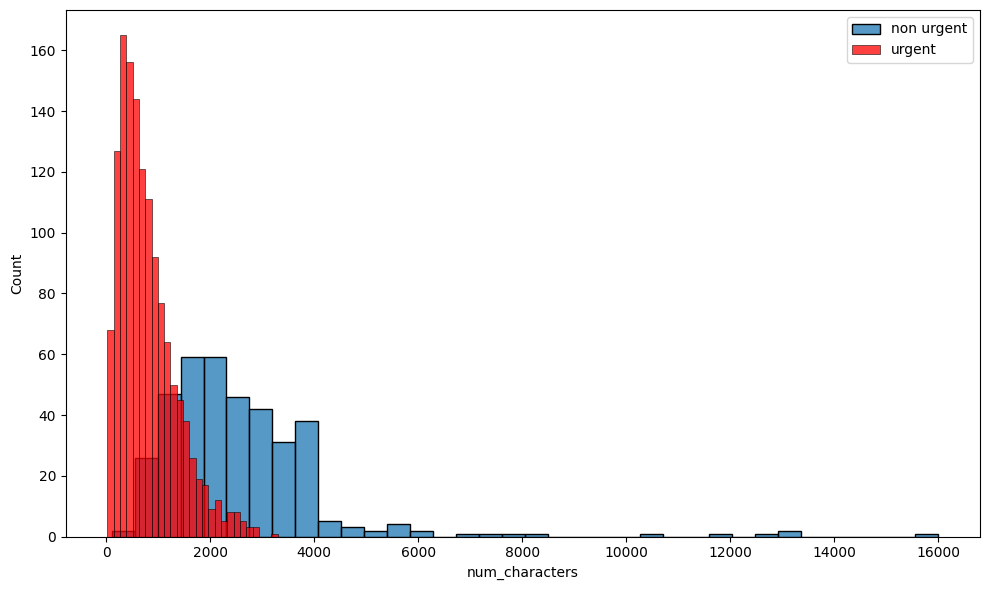

In [37]:
plt.figure(figsize=(10,6))
sns.histplot(df[df['Priority']==0]['num_characters'],label='non urgent')
sns.histplot(df[df['Priority']==1]['num_characters'],color='red',label='urgent')
plt.legend()
plt.tight_layout()
plt.show()

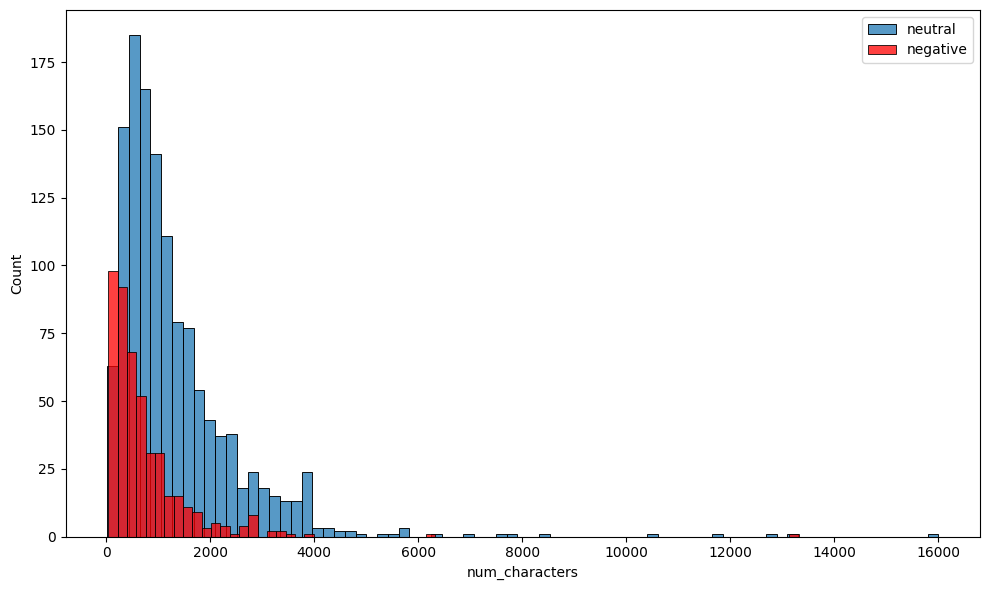

In [38]:
plt.figure(figsize=(10,6))
sns.histplot(df[df['Sentiment']==0]['num_characters'],label='neutral')
sns.histplot(df[df['Sentiment']==1]['num_characters'],color='red',label='negative')
plt.legend()
plt.tight_layout()
plt.show()

The histograms reveal that non-urgent and neutral complaints are generally longer and more variable in length, whereas urgent and negative complaints tend to be shorter and concentrated within lower character ranges. Both distributions exhibit positive skewness due to the presence of a small number of extremely long complaints.

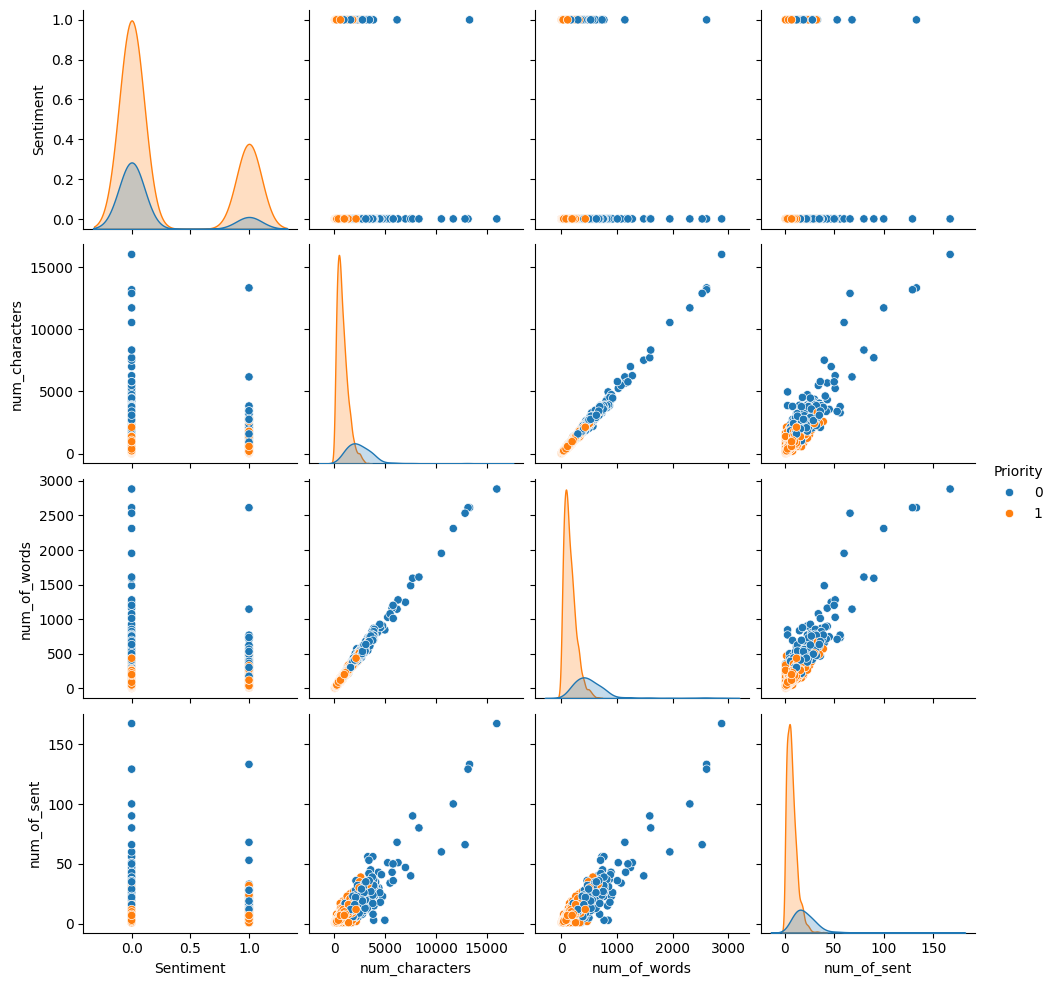

In [39]:
sns.pairplot(df, hue ='Priority')

In [40]:
data= df.drop(columns=['Consumer_complaint','Product'])

<Axes: >

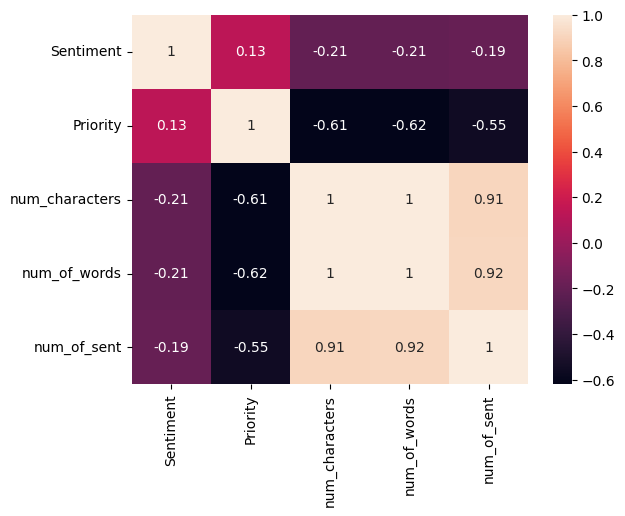

In [41]:
sns.heatmap(data.corr(),annot=True)

Overall, complaint length features are highly correlated with one another and provide useful information regarding complaint complexity. These features exhibit a stronger relationship with complaint priority than with sentiment, indicating that complaint length may be more effective for predicting urgency than for determining customer sentiment.

due the presence of very high correlation between them we will only keep on of feature (i.e num_character, num_of_words and num_of_sent)which has high correlation with the target variable viz priority.

## Data Preprocessing

creating a function that could perform these operations
- Lower case
- Tokenization
- Removing special characters
- Removing stop words and punctuation
- Stemming

In [42]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [43]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [44]:
from nltk.stem import PorterStemmer
ps = PorterStemmer()

In [45]:
def transform_text(text):
    #lower case
    text = text.lower()
    #Tokenization
    text = nltk.word_tokenize(text)
    # removing special characters
    y=[]
    for i in text:
        if i.isalnum() and i != 'xxxx':
            y.append(i)
    # removing stop words and punctuation
    text = y[:]
    y.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    # stemming
    text= y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))
    
    return " ".join(y)

In [46]:
#optimize form of the above function
stop_words = set(stopwords.words('english'))
mask_words = {'xxxx', 'xxx', 'xx'}

def trans_text(text):
    tokens = nltk.word_tokenize(text.lower())

    processed = [
        ps.stem(word)
        for word in tokens
        if word.isalnum()
        and word not in stop_words
        and word not in mask_words
    ]

    return " ".join(processed)

In [47]:
df['Consumer_complaint'][100]

'I tried to authorize the app, " XXXX \'\' to use my Capital One 360 account but Capital One is blocking this feature. \n\nI should be able to pay for things with my money wherever and however I choose.'

In [48]:
trans_text(df['Consumer_complaint'][100])

'tri author app use capit one 360 account capit one block featur abl pay thing money wherev howev choos'

In [49]:
df['trans_text'] = df['Consumer_complaint'].apply(trans_text)

In [50]:
df.sample(5)

,Consumer_complaint,Product,Sentiment,Priority,num_characters,num_of_words,num_of_sent,trans_text
1246,i am a XXXX on pension vet..i had XXXX every w...,"Credit reporting, repair, or other",0,1,902,198,1,pension vet everi week sourc va sent local hos...
303,I have XXXX via the state of Georgia on my Tra...,"Credit reporting, repair, or other",1,1,166,31,2,via state georgia transunion credit report att...
639,"In summary, I have made a EUR withdrawal from ...","Money transfer, virtual currency, or money ser...",1,0,6171,1144,68,summari made eur withdraw coinbas irish bank a...
1075,"On XX/XX/2014, I paid a bill over the phone fo...",Credit card or prepaid card,1,1,545,109,6,paid bill phone daughter card compani card iss...
736,"On XXXX XXXX, 2016, I odered a XXXX product fr...","Money transfer, virtual currency, or money ser...",0,1,1530,325,25,2016 oder product onlin paid full paypal accou...


### Word Cloud Analysis

In [51]:
from wordcloud import WordCloud
wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
)

In [52]:
non_urgent_wc = wc.generate(df[df['Priority']==0]['trans_text'].str.cat(sep=" "))

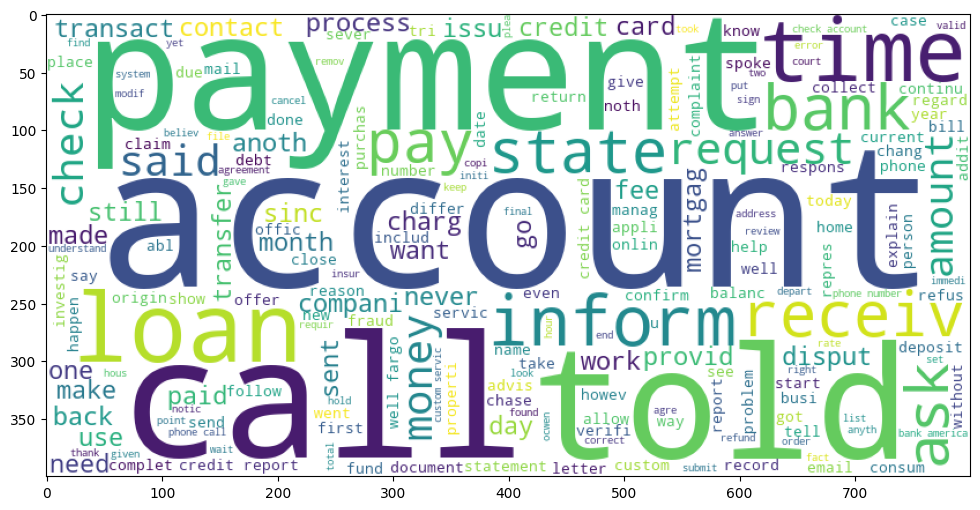

In [53]:
plt.figure(figsize=(15,6))
plt.imshow(non_urgent_wc)

In [54]:
urgent_wc = wc.generate(df[df['Priority']==1]['trans_text'].str.cat(sep=" "))

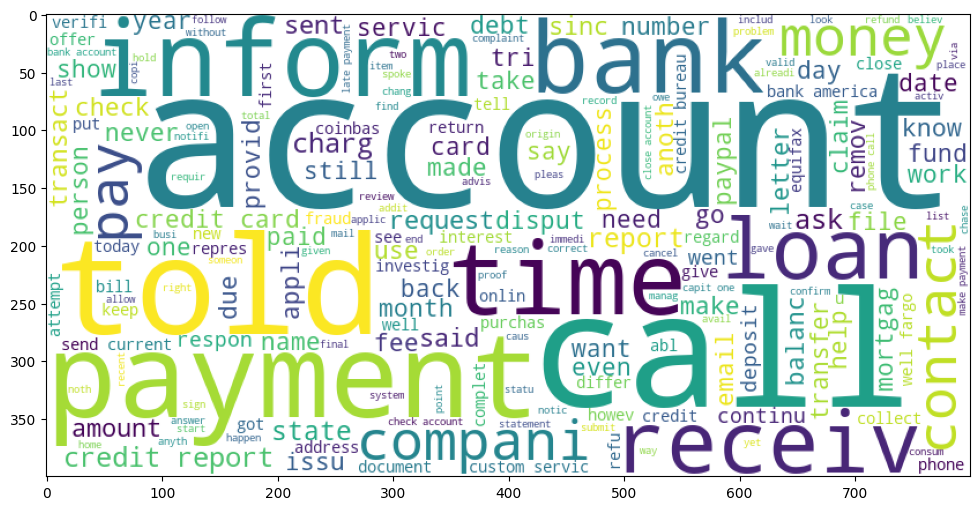

In [55]:
plt.figure(figsize=(15,6))
plt.imshow(urgent_wc)

The word clouds reveal that both urgent and non-urgent complaints frequently contain terms such as account, payment, bank, and loan, indicating that these topics are common across consumer complaints. However, urgent complaints show a greater emphasis on words related to financial transactions, disputes, and credit-related issues. The similarity between the two word clouds suggests that complaint priority cannot be determined by individual keywords alone. Therefore, more advanced NLP techniques are required to capture the contextual differences between urgent and non-urgent complaints.

# Model Building 

In [56]:
df.sample(10)

,Consumer_complaint,Product,Sentiment,Priority,num_characters,num_of_words,num_of_sent,trans_text
1749,On XX/XX/2016 we closed on a loan with Pure Mo...,Mortgage,0,1,974,198,7,close loan pure mortgag includ final cd loan d...
55,A check was written to pay for day care servic...,Checking or savings account or service,1,1,562,123,7,check written pay day care servic sign check w...
321,Experian deliberately discourages customers ab...,"Credit reporting, repair, or other",0,1,645,108,5,experian deliber discourag custom abil submit ...
444,Southwest Credit Systems on behalf of XXXX rep...,Debt collection,0,1,802,145,9,southwest credit system behalf report derogato...
279,"Report # XXXX Attention : Consumer Relations, ...","Credit reporting, repair, or other",0,0,1570,311,18,report attent consum relat recent obtain copi ...
996,Bank of America LOST MY MONEY. Despite numerou...,Checking or savings account or service,0,1,839,171,9,bank america lost money despit numer attempt r...
195,I understand that there are no laws regarding ...,Credit card or prepaid card,0,1,1088,221,8,understand law regard bank right decreas consu...
910,On XX/XX/XXXX a charge from XXXX was to come o...,Checking or savings account or service,1,1,776,152,6,charg come account amount jp morgan chase bank...
78,Paypal limited my account and withheld my fund...,Checking or savings account or service,0,1,499,95,6,paypal limit account withheld fund explan call...
620,I recieved a car loan from XXXX XXXX acceptanc...,Loans,0,0,3522,703,26,reciev car loan accept car purchas lemon left ...


since num of characters , words and sentences are highly correlated hence keeping only number of words as it has high linear relationship with priority of consumer complains

In [57]:
# removing Consumer_complaint, num_characters and num_of_sent
df_ml = df.drop(columns=['Consumer_complaint','num_characters','num_of_sent'])

In [58]:
df_ml.sample(10)

,Product,Sentiment,Priority,num_of_words,trans_text
980,Checking or savings account or service,0,1,178,fraudul transact person check account somehow ...
445,Debt collection,1,1,36,credit system 3rd parti collect agenc contract...
329,"Credit reporting, repair, or other",0,0,656,get experian experian conduct real reason inve...
1393,Loans,0,1,109,ae incorrectli report student loan account der...
315,"Credit reporting, repair, or other",0,1,240,open bank account told dat later account would...
1472,Loans,0,1,157,switch incom base repay plan prior enrol recei...
587,Loans,1,0,747,sign locat attend 9 month diploma medic assist...
1353,Debt collection,0,0,383,regard gold key credit work make sure credit r...
1663,Mortgage,0,0,2611,summari date phone call notic receiv point con...
60,Checking or savings account or service,1,1,205,despit effort keep substanti amount avail fund...


## Bag of words

In [59]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer([
    ('onehot', OneHotEncoder(drop='first'), ['Product']),
    ('cv', CountVectorizer(max_features=5000), 'trans_text')
], remainder='passthrough')

In [60]:
# train test split
X = df_ml.drop(columns=['Priority'])
y = df_ml['Priority']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [61]:
X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)

In [62]:
print(X_train.shape)
print(X_test.shape)

(1400, 5008)
(350, 5008)


### i) Multinomial Naive Bayes

In [63]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train, y_train)

pred_nb1 = nb.predict(X_test)

In [64]:
from sklearn.metrics import *

print(confusion_matrix(y_test, pred_nb1))
print("Accuracy :", accuracy_score(y_test, pred_nb1))
print("Precision:", precision_score(y_test, pred_nb1))
print("Recall   :", recall_score(y_test, pred_nb1))
print("F1 Score :", f1_score(y_test, pred_nb1))

[[ 37  38]
 [ 43 232]]
Accuracy : 0.7685714285714286
Precision: 0.8592592592592593
Recall   : 0.8436363636363636
F1 Score : 0.8513761467889909


## ii) Bernoulli Naive Bayes

In [65]:
from sklearn.naive_bayes import BernoulliNB

bnb = BernoulliNB()
bnb.fit(X_train, y_train)

pred_bnb1 = bnb.predict(X_test)

In [66]:
from sklearn.metrics import *

print(confusion_matrix(y_test, pred_bnb1))
print("Accuracy :", accuracy_score(y_test, pred_bnb1))
print("Precision:", precision_score(y_test, pred_bnb1))
print("Recall   :", recall_score(y_test, pred_bnb1))
print("F1 Score :", f1_score(y_test, pred_bnb1))

[[ 51  24]
 [ 11 264]]
Accuracy : 0.9
Precision: 0.9166666666666666
Recall   : 0.96
F1 Score : 0.9378330373001776


## iii) Complement Naive Bayes

In [67]:
from sklearn.naive_bayes import ComplementNB

cnb = ComplementNB()
cnb.fit(X_train, y_train)

pred_cnb1= cnb.predict(X_test)

In [68]:
from sklearn.metrics import *

print(confusion_matrix(y_test, pred_cnb1))
print("Accuracy :", accuracy_score(y_test, pred_cnb1))
print("Precision:", precision_score(y_test, pred_cnb1))
print("Recall   :", recall_score(y_test, pred_cnb1))
print("F1 Score :", f1_score(y_test, pred_cnb1))

[[ 39  36]
 [ 56 219]]
Accuracy : 0.7371428571428571
Precision: 0.8588235294117647
Recall   : 0.7963636363636364
F1 Score : 0.8264150943396227


## iv) Logistic Regression

In [69]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=2000)

lr.fit(X_train, y_train)

pred_lr1 = lr.predict(X_test)

In [70]:
from sklearn.metrics import *

print(confusion_matrix(y_test, pred_lr1))
print("Accuracy :", accuracy_score(y_test, pred_lr1))
print("Precision:", precision_score(y_test, pred_lr1))
print("Recall   :", recall_score(y_test, pred_lr1))
print("F1 Score :", f1_score(y_test, pred_lr1))

[[ 42  33]
 [ 17 258]]
Accuracy : 0.8571428571428571
Precision: 0.8865979381443299
Recall   : 0.9381818181818182
F1 Score : 0.911660777385159


## v) Linear SVM

In [71]:
from sklearn.svm import LinearSVC

svm = LinearSVC()

svm.fit(X_train, y_train)

pred_svm1 = svm.predict(X_test)

C:\Users\aishw\.conda\envs\finance\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [72]:
from sklearn.metrics import *

print(confusion_matrix(y_test, pred_svm1))
print("Accuracy :", accuracy_score(y_test, pred_svm1))
print("Precision:", precision_score(y_test, pred_svm1))
print("Recall   :", recall_score(y_test, pred_svm1))
print("F1 Score :", f1_score(y_test, pred_svm1))

[[ 25  50]
 [  8 267]]
Accuracy : 0.8342857142857143
Precision: 0.8422712933753943
Recall   : 0.9709090909090909
F1 Score : 0.902027027027027


In [73]:
# comparing the results 
results = pd.DataFrame({
    'Model':['MultinomialNB','BinomialNB','ComplementNB','Logistic Regression','Linear SVM'],
    'Accuracy':[accuracy_score(y_test, pred_nb1),accuracy_score(y_test, pred_bnb1),accuracy_score(y_test, pred_cnb1),accuracy_score(y_test, pred_lr1),accuracy_score(y_test, pred_svm1)],
    'Precision':[precision_score(y_test, pred_nb1),precision_score(y_test, pred_bnb1),precision_score(y_test, pred_cnb1),precision_score(y_test, pred_lr1),precision_score(y_test, pred_svm1)],
    'Recall':[recall_score(y_test, pred_nb1),recall_score(y_test, pred_bnb1),recall_score(y_test, pred_cnb1),recall_score(y_test, pred_lr1),recall_score(y_test, pred_svm1)],
    'F1':[f1_score(y_test, pred_nb1),f1_score(y_test, pred_bnb1),f1_score(y_test, pred_cnb1),f1_score(y_test, pred_lr1),f1_score(y_test, pred_svm1)]
})

results.sort_values(by='Precision')

,Model,Accuracy,Precision,Recall,F1
4,Linear SVM,0.834286,0.842271,0.970909,0.902027
2,ComplementNB,0.737143,0.858824,0.796364,0.826415
0,MultinomialNB,0.768571,0.859259,0.843636,0.851376
3,Logistic Regression,0.857143,0.886598,0.938182,0.911661
1,BinomialNB,0.900000,0.916667,0.960000,0.937833


Multiple machine learning models were evaluated using Bag-of-Words features for complaint priority classification. Among all models, Bernoulli Naive Bayes achieved the best overall performance, with an accuracy of 90.0%, precision of 91.7%, recall of 96.0%, and F1-score of 93.8%. This indicates that the presence or absence of specific words is highly informative for distinguishing urgent and non-urgent complaints. Logistic Regression and Linear SVM also performed well but were slightly inferior across most evaluation metrics.

---

## TF-Idf

In [74]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct2 = ColumnTransformer([
    ('onehot', OneHotEncoder(drop='first'), ['Product']),
    ('TFIdf', TfidfVectorizer(), 'trans_text')
], remainder='passthrough')

In [75]:
# train test split
X = df_ml.drop(columns=['Priority'])
y = df_ml['Priority']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [76]:
X_train = ct2.fit_transform(X_train)
X_test = ct2.transform(X_test)

In [77]:
print(X_train.shape)
print(X_test.shape)

(1400, 5496)
(350, 5496)


### i) Multinomial Naive Bayes

In [78]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train, y_train)

pred_nb2 = nb.predict(X_test)

In [79]:
## from sklearn.metrics import *

print(confusion_matrix(y_test, pred_nb2))
print("Accuracy :", accuracy_score(y_test, pred_nb2))
print("Precision:", precision_score(y_test, pred_nb2))
print("Recall   :", recall_score(y_test, pred_nb2))
print("F1 Score :", f1_score(y_test, pred_nb2))

[[ 56  19]
 [ 22 253]]
Accuracy : 0.8828571428571429
Precision: 0.9301470588235294
Recall   : 0.92
F1 Score : 0.9250457038391224


## ii) Bernoulli Naive Bayes

In [80]:
from sklearn.naive_bayes import BernoulliNB

bnb = BernoulliNB()
bnb.fit(X_train, y_train)

pred_bnb2 = bnb.predict(X_test)

In [81]:
from sklearn.metrics import *

print(confusion_matrix(y_test, pred_bnb2))
print("Accuracy :", accuracy_score(y_test, pred_bnb2))
print("Precision:", precision_score(y_test, pred_bnb2))
print("Recall   :", recall_score(y_test, pred_bnb2))
print("F1 Score :", f1_score(y_test, pred_bnb2))

[[ 49  26]
 [  9 266]]
Accuracy : 0.9
Precision: 0.910958904109589
Recall   : 0.9672727272727273
F1 Score : 0.9382716049382716


## iii) Complement Naive Bayes

In [82]:
from sklearn.naive_bayes import ComplementNB

cnb = ComplementNB()
cnb.fit(X_train, y_train)

pred_cnb2 = cnb.predict(X_test)

In [83]:
from sklearn.metrics import *

print(confusion_matrix(y_test, pred_cnb2))
print("Accuracy :", accuracy_score(y_test, pred_cnb2))
print("Precision:", precision_score(y_test, pred_cnb2))
print("Recall   :", recall_score(y_test, pred_cnb2))
print("F1 Score :", f1_score(y_test, pred_cnb2))

[[ 67   8]
 [ 59 216]]
Accuracy : 0.8085714285714286
Precision: 0.9642857142857143
Recall   : 0.7854545454545454
F1 Score : 0.8657314629258517


## iv) Logistic Regression

In [84]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=2000)

lr.fit(X_train, y_train)

pred_lr2 = lr.predict(X_test)

In [85]:
from sklearn.metrics import *

print(confusion_matrix(y_test, pred_lr2))
print("Accuracy :", accuracy_score(y_test, pred_lr2))
print("Precision:", precision_score(y_test, pred_lr2))
print("Recall   :", recall_score(y_test, pred_lr2))
print("F1 Score :", f1_score(y_test, pred_lr2))

[[ 42  33]
 [  7 268]]
Accuracy : 0.8857142857142857
Precision: 0.8903654485049833
Recall   : 0.9745454545454545
F1 Score : 0.9305555555555556


## v) Linear SVM

In [86]:
from sklearn.svm import LinearSVC

svm = LinearSVC()

svm.fit(X_train, y_train)

pred_svm2 = svm.predict(X_test)

C:\Users\aishw\.conda\envs\finance\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [87]:
from sklearn.metrics import *

print(confusion_matrix(y_test, pred_svm2))
print("Accuracy :", accuracy_score(y_test, pred_svm2))
print("Precision:", precision_score(y_test, pred_svm2))
print("Recall   :", recall_score(y_test, pred_svm2))
print("F1 Score :", f1_score(y_test, pred_svm2))

[[  2  73]
 [  0 275]]
Accuracy : 0.7914285714285715
Precision: 0.7902298850574713
Recall   : 1.0
F1 Score : 0.8828250401284109


### vi) Random Forest

Text data after TF-IDF is extremely high-dimensional and sparse. Linear models such as Logistic Regression and SVM are generally more suitable and computationally efficient. However, I also evaluated ensemble methods like Random Forest/XGBoost to determine whether non-linear decision boundaries could improve classification performance.

In [88]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred_rf2 = rf.predict(X_test)

In [89]:
from sklearn.metrics import *

print(confusion_matrix(y_test, pred_rf2))
print("Accuracy :", accuracy_score(y_test, pred_rf2))
print("Precision:", precision_score(y_test, pred_rf2))
print("Recall   :", recall_score(y_test, pred_rf2))
print("F1 Score :", f1_score(y_test, pred_rf2))

[[ 20  55]
 [  1 274]]
Accuracy : 0.84
Precision: 0.8328267477203647
Recall   : 0.9963636363636363
F1 Score : 0.9072847682119205


In [90]:
# comparing the results 
results = pd.DataFrame({
    'Model':['MultinomialNB','BinomialNB','ComplementNB','Logistic Regression','Linear SVM','Random Forest'],
    'Accuracy':[accuracy_score(y_test, pred_nb2),accuracy_score(y_test, pred_bnb2),accuracy_score(y_test, pred_cnb2),accuracy_score(y_test, pred_lr2),accuracy_score(y_test, pred_svm2),accuracy_score(y_test, pred_rf2)],
    'Precision':[precision_score(y_test, pred_nb2),precision_score(y_test, pred_bnb2),precision_score(y_test, pred_cnb2),precision_score(y_test, pred_lr2),precision_score(y_test, pred_svm2),precision_score(y_test, pred_rf2)],
    'Recall':[recall_score(y_test, pred_nb2),recall_score(y_test, pred_bnb2),recall_score(y_test, pred_cnb2),recall_score(y_test, pred_lr2),recall_score(y_test, pred_svm2),recall_score(y_test, pred_rf2)],
    'F1':[f1_score(y_test, pred_nb2),f1_score(y_test, pred_bnb2),f1_score(y_test, pred_cnb2),f1_score(y_test, pred_lr2),f1_score(y_test, pred_svm2),f1_score(y_test, pred_rf2)]
})

results.sort_values(by='Precision')

,Model,Accuracy,Precision,Recall,F1
4,Linear SVM,0.791429,0.790230,1.000000,0.882825
5,Random Forest,0.840000,0.832827,0.996364,0.907285
3,Logistic Regression,0.885714,0.890365,0.974545,0.930556
1,BinomialNB,0.900000,0.910959,0.967273,0.938272
0,MultinomialNB,0.882857,0.930147,0.920000,0.925046
2,ComplementNB,0.808571,0.964286,0.785455,0.865731


Using TF-IDF features, Linear SVM emerged as the best-performing classifier, achieving the highest accuracy (90.9%) and F1-score (94.2%) while maintaining a high recall (95.3%). These results indicate that TF-IDF combined with Linear SVM effectively captures important textual patterns for complaint priority classification and provides a strong balance between precision and recall.

---

## Sentence Bert embedding

In [91]:
# train test split
from sklearn.model_selection import train_test_split

X = df_ml.drop('Priority', axis=1)
y = df_ml['Priority']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [92]:
#Generate Sentence-BERT Embeddings

from sentence_transformers import SentenceTransformer

sbert = SentenceTransformer('all-MiniLM-L6-v2')

X_train_emb = sbert.encode(
    X_train['trans_text'].tolist(),
    show_progress_bar=True
)

X_test_emb = sbert.encode(
    X_test['trans_text'].tolist(),
    show_progress_bar=True
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/44 [00:00<?, ?it/s]

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

In [93]:
print(X_train_emb.shape)

(1400, 384)


In [94]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(
    drop='first',
    sparse_output=False,
    handle_unknown='ignore'
)

product_train = ohe.fit_transform(X_train[['Product']])

product_test = ohe.transform(X_test[['Product']])

In [95]:
print(product_train.shape)

(1400, 6)


In [96]:
num_train = X_train[['Sentiment','num_of_words']].values
num_test = X_test[['Sentiment','num_of_words']].values

In [97]:
import numpy as np

X_train_final = np.hstack([
    X_train_emb,
    product_train,
    num_train
])

X_test_final = np.hstack([
    X_test_emb,
    product_test,
    num_test
])

In [98]:
print(X_train_final.shape)
print(X_test_final.shape)

(1400, 392)
(350, 392)


## i) Gaussian NB

Gaussian Naive Bayes was employed for Sentence-BERT embeddings because the embeddings are dense continuous-valued vectors. Unlike Multinomial and Bernoulli Naive Bayes, which are designed for count-based and binary text representations respectively, Gaussian Naive Bayes is appropriate for continuous feature spaces. This allowed the evaluation of a probabilistic classifier on semantic sentence embeddings and provided a meaningful comparison with Logistic Regression, Linear SVM, and Random Forest.

In [99]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()

gnb.fit(X_train_final, y_train)

pred_gnb = gnb.predict(X_test_final)

In [100]:
from sklearn.metrics import *

print(confusion_matrix(y_test, pred_gnb))
print("Accuracy :", accuracy_score(y_test, pred_gnb))
print("Precision:", precision_score(y_test, pred_gnb))
print("Recall   :", recall_score(y_test, pred_gnb))
print("F1 Score :", f1_score(y_test, pred_gnb))

[[ 60  15]
 [ 33 242]]
Accuracy : 0.8628571428571429
Precision: 0.9416342412451362
Recall   : 0.88
F1 Score : 0.9097744360902256


## ii) Logistics Regression

In [101]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=2000)

lr.fit(X_train_final, y_train)

pred_lr = lr.predict(X_test_final)

In [102]:
from sklearn.metrics import *

print(confusion_matrix(y_test, pred_lr))
print("Accuracy :", accuracy_score(y_test, pred_lr))
print("Precision:", precision_score(y_test, pred_lr))
print("Recall   :", recall_score(y_test, pred_lr))
print("F1 Score :", f1_score(y_test, pred_lr))

[[ 40  35]
 [  8 267]]
Accuracy : 0.8771428571428571
Precision: 0.8841059602649006
Recall   : 0.9709090909090909
F1 Score : 0.925476603119584


TFidf performed better in terms of sent bert and BOW for linear regression.
very small difference is seen in tfidf and sent BERT.

## iii) Linear SVM

In [103]:
from sklearn.svm import LinearSVC

svm = LinearSVC()

svm.fit(X_train_final, y_train)

pred_svm = svm.predict(X_test_final)

In [104]:
from sklearn.metrics import *

print(confusion_matrix(y_test, pred_lr))
print("Accuracy :", accuracy_score(y_test, pred_svm))
print("Precision:", precision_score(y_test, pred_svm))
print("Recall   :", recall_score(y_test, pred_svm))
print("F1 Score :", f1_score(y_test, pred_svm))

[[ 40  35]
 [  8 267]]
Accuracy : 0.8857142857142857
Precision: 0.8929765886287625
Recall   : 0.9709090909090909
F1 Score : 0.9303135888501742


in this case too tfid performed slightly better than sentece bert. 

## iv) Random Forest

In [105]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_final, y_train)

pred_rf = rf.predict(X_test_final)

In [106]:
from sklearn.metrics import *

print(confusion_matrix(y_test, pred_rf))
print("Accuracy :", accuracy_score(y_test, pred_rf))
print("Precision:", precision_score(y_test, pred_rf))
print("Recall   :", recall_score(y_test, pred_rf))
print("F1 Score :", f1_score(y_test, pred_rf))

[[ 49  26]
 [  9 266]]
Accuracy : 0.9
Precision: 0.910958904109589
Recall   : 0.9672727272727273
F1 Score : 0.9382716049382716


in case of random forest sentence bert tend to perform better than tfidf there is a significant difference between there performance.

In [107]:
# comparing the results 
results = pd.DataFrame({
    'Model':['GaussianNB','Logistic Regression','Linear SVM','Random Forest'],
    'Accuracy':[accuracy_score(y_test, pred_gnb),accuracy_score(y_test, pred_lr),accuracy_score(y_test, pred_svm),accuracy_score(y_test, pred_rf)],
    'Precision':[precision_score(y_test, pred_gnb),precision_score(y_test, pred_lr),precision_score(y_test, pred_svm),precision_score(y_test, pred_rf)],
    'Recall':[recall_score(y_test, pred_gnb),recall_score(y_test, pred_lr),recall_score(y_test, pred_svm),recall_score(y_test, pred_rf)],
    'F1':[f1_score(y_test, pred_gnb),f1_score(y_test, pred_lr),f1_score(y_test, pred_svm),f1_score(y_test, pred_rf)]
})

results.sort_values(by='Precision')

,Model,Accuracy,Precision,Recall,F1
1,Logistic Regression,0.877143,0.884106,0.970909,0.925477
2,Linear SVM,0.885714,0.892977,0.970909,0.930314
3,Random Forest,0.900000,0.910959,0.967273,0.938272
0,GaussianNB,0.862857,0.941634,0.880000,0.909774


Using Sentence-BERT embeddings, four classification models were evaluated: Gaussian Naive Bayes, Logistic Regression, Linear SVM, and Random Forest. Random Forest achieved the best overall performance with an accuracy of 90.0%, precision of 91.1%, recall of 96.7%, and F1-score of 93.8%. Although Logistic Regression and Linear SVM achieved marginally higher recall, Random Forest provided the best balance between correctly identifying urgent complaints and minimizing false alarms. Therefore, Random Forest was selected as the final model for complaint priority classification.

## v) XGBoost

In [108]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train_final, y_train)

pred_xgb = xgb.predict(X_test_final)

In [109]:
from sklearn.metrics import *

print(confusion_matrix(y_test, pred_xgb))
print("Accuracy :", accuracy_score(y_test, pred_xgb))
print("Precision:", precision_score(y_test, pred_xgb))
print("Recall   :", recall_score(y_test, pred_xgb))
print("F1 Score :", f1_score(y_test, pred_xgb))

[[ 45  30]
 [  8 267]]
Accuracy : 0.8914285714285715
Precision: 0.898989898989899
Recall   : 0.9709090909090909
F1 Score : 0.9335664335664335


In [110]:
results.loc[len(results)] = ['XGBoost', accuracy_score(y_test, pred_xgb),precision_score(y_test, pred_xgb),recall_score(y_test, pred_xgb),f1_score(y_test, pred_xgb)]

results.sort_values(by='Precision')

,Model,Accuracy,Precision,Recall,F1
1,Logistic Regression,0.877143,0.884106,0.970909,0.925477
2,Linear SVM,0.885714,0.892977,0.970909,0.930314
4,XGBoost,0.891429,0.898990,0.970909,0.933566
3,Random Forest,0.900000,0.910959,0.967273,0.938272
0,GaussianNB,0.862857,0.941634,0.880000,0.909774


In [111]:
# final comparision table

overall_results = pd.DataFrame({

    'Feature_Representation':[
        'Bag of Words','Bag of Words','Bag of Words','Bag of Words','Bag of Words',
        'TF-IDF','TF-IDF','TF-IDF','TF-IDF','TF-IDF','TF-IDF',
        'Sentence-BERT','Sentence-BERT','Sentence-BERT','Sentence-BERT'
    ],

    'Model':[
        'MultinomialNB','BinomialNB','ComplementNB','Logistic Regression','Linear SVM',
        'MultinomialNB','BinomialNB','ComplementNB','Logistic Regression','Linear SVM','Random Forest',
        'GaussianNB','Logistic Regression','Linear SVM','Random Forest'
    ],

    'Accuracy':[
        accuracy_score(y_test,pred_nb1),
        accuracy_score(y_test,pred_bnb1),
        accuracy_score(y_test,pred_cnb1),
        accuracy_score(y_test,pred_lr1),
        accuracy_score(y_test,pred_svm1),

        accuracy_score(y_test,pred_nb2),
        accuracy_score(y_test,pred_bnb2),
        accuracy_score(y_test,pred_cnb2),
        accuracy_score(y_test,pred_lr2),
        accuracy_score(y_test,pred_svm2),
        accuracy_score(y_test,pred_rf2),

        accuracy_score(y_test,pred_gnb),
        accuracy_score(y_test,pred_lr),
        accuracy_score(y_test,pred_svm),
        accuracy_score(y_test,pred_rf)
    ],

    'Precision':[
        precision_score(y_test,pred_nb1),
        precision_score(y_test,pred_bnb1),
        precision_score(y_test,pred_cnb1),
        precision_score(y_test,pred_lr1),
        precision_score(y_test,pred_svm1),

        precision_score(y_test,pred_nb2),
        precision_score(y_test,pred_bnb2),
        precision_score(y_test,pred_cnb2),
        precision_score(y_test,pred_lr2),
        precision_score(y_test,pred_svm2),
        precision_score(y_test,pred_rf2),

        precision_score(y_test,pred_gnb),
        precision_score(y_test,pred_lr),
        precision_score(y_test,pred_svm),
        precision_score(y_test,pred_rf)
    ],

    'Recall':[
        recall_score(y_test,pred_nb1),
        recall_score(y_test,pred_bnb1),
        recall_score(y_test,pred_cnb1),
        recall_score(y_test,pred_lr1),
        recall_score(y_test,pred_svm1),

        recall_score(y_test,pred_nb2),
        recall_score(y_test,pred_bnb2),
        recall_score(y_test,pred_cnb2),
        recall_score(y_test,pred_lr2),
        recall_score(y_test,pred_svm2),
        recall_score(y_test,pred_rf2),

        recall_score(y_test,pred_gnb),
        recall_score(y_test,pred_lr),
        recall_score(y_test,pred_svm),
        recall_score(y_test,pred_rf)
    ],

    'F1':[
        f1_score(y_test,pred_nb1),
        f1_score(y_test,pred_bnb1),
        f1_score(y_test,pred_cnb1),
        f1_score(y_test,pred_lr1),
        f1_score(y_test,pred_svm1),

        f1_score(y_test,pred_nb2),
        f1_score(y_test,pred_bnb2),
        f1_score(y_test,pred_cnb2),
        f1_score(y_test,pred_lr2),
        f1_score(y_test,pred_svm2),
        f1_score(y_test,pred_rf2),

        f1_score(y_test,pred_gnb),
        f1_score(y_test,pred_lr),
        f1_score(y_test,pred_svm),
        f1_score(y_test,pred_rf)
    ]
})

overall_results.sort_values(
    by=['F1','Recall'],
    ascending=False
).reset_index(drop=True)

,Feature_Representation,Model,Accuracy,Precision,Recall,F1
0,TF-IDF,BinomialNB,0.900000,0.910959,0.967273,0.938272
1,Sentence-BERT,Random Forest,0.900000,0.910959,0.967273,0.938272
2,Bag of Words,BinomialNB,0.900000,0.916667,0.960000,0.937833
3,TF-IDF,Logistic Regression,0.885714,0.890365,0.974545,0.930556
4,Sentence-BERT,Linear SVM,0.885714,0.892977,0.970909,0.930314
5,Sentence-BERT,Logistic Regression,0.877143,0.884106,0.970909,0.925477
6,TF-IDF,MultinomialNB,0.882857,0.930147,0.920000,0.925046
7,Bag of Words,Logistic Regression,0.857143,0.886598,0.938182,0.911661
8,Sentence-BERT,GaussianNB,0.862857,0.941634,0.880000,0.909774
9,TF-IDF,Random Forest,0.840000,0.832827,0.996364,0.907285


- TF-IDF + Linear SVM achieved the best overall performance with:
    - Accuracy = 90.86%
    - Precision = 93.24%
    - Recall = 95.27%
    - F1 Score = 94.24%
- TF-IDF + BinomialNB, Sentence-BERT + Random Forest, and Bag of Words + BinomialNB all performed very closely, with F1 scores around 93.8%.
- Surprisingly, Sentence-BERT did not significantly outperform TF-IDF, despite being a much more sophisticated embedding technique. This suggests that the urgency information is largely captured by specific keywords and phrases rather than deeper semantic relationships.
- The TF-IDF representation consistently produced the strongest models, indicating that term frequency patterns are highly informative for complaint priority classification.

Hyperparameter tunning the first three best model

---

### Random Forest + Sentence BERT

In [112]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, None],
    'class_weight': [None, 'balanced']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_rf.fit(X_train_final, y_train)

print("Best Parameters:", grid_rf.best_params_)
print("Best CV Score:", grid_rf.best_score_)

Best Parameters: {'class_weight': None, 'max_depth': None, 'n_estimators': 200}
Best CV Score: 0.9277324632575935


In [113]:
best_rf = grid_rf.best_estimator_

pred_rf_best = best_rf.predict(X_test_final)

print(confusion_matrix(y_test, pred_rf_best))
print("Accuracy :", accuracy_score(y_test, pred_rf_best))
print("Precision:", precision_score(y_test, pred_rf_best))
print("Recall   :", recall_score(y_test, pred_rf_best))
print("F1 Score :", f1_score(y_test, pred_rf_best))

[[ 49  26]
 [  9 266]]
Accuracy : 0.9
Precision: 0.910958904109589
Recall   : 0.9672727272727273
F1 Score : 0.9382716049382716


Random Forest trained on Sentence-BERT embeddings achieved strong performance with an accuracy of 90.0% and F1-score of 93.8%. Hyperparameter tuning did not improve the results, indicating that the initial model configuration was already well-suited to the dataset.

### TF-IDF + Linear SVM

In [114]:
# train test split
X = df_ml.drop(columns=['Priority'])
y = df_ml['Priority']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [115]:
X_train_tfidf = ct2.fit_transform(X_train)
X_test_tfidf = ct2.transform(X_test)

In [116]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC

param_grid_svm = {
    'C':[0.001,0.01,0.1,1,10],
    'class_weight':[None,'balanced']
}

grid_svm = GridSearchCV(
    LinearSVC(random_state=42),
    param_grid_svm,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_svm.fit(X_train_tfidf, y_train)

print("Best Parameters:", grid_svm.best_params_)
print("Best CV Score:", grid_svm.best_score_)

Best Parameters: {'C': 0.001, 'class_weight': None}
Best CV Score: 0.9244423988055601


C:\Users\aishw\.conda\envs\finance\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [117]:
best_svm = grid_svm.best_estimator_

pred_svm_best = best_svm.predict(X_test_tfidf)

print(confusion_matrix(y_test,pred_svm_best))
print("Accuracy :",accuracy_score(y_test,pred_svm_best))
print("Precision:",precision_score(y_test,pred_svm_best))
print("Recall   :",recall_score(y_test,pred_svm_best))
print("F1 Score :",f1_score(y_test,pred_svm_best))

[[ 30  45]
 [  4 271]]
Accuracy : 0.86
Precision: 0.8575949367088608
Recall   : 0.9854545454545455
F1 Score : 0.9170896785109983


Hyperparameter tuning increased recall from 95.3% to 98.5%, reducing false negatives from 13 to 4. Although precision and overall F1-score decreased slightly, the tuned model is preferable in the context of urgent complaint detection, where failing to identify a genuinely urgent complaint is more costly than incorrectly flagging a non-urgent complaint as urgent.

## TF IDF + Binomial NB

In [118]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import GridSearchCV

param_grid_bnb = {
    'alpha': [0.001, 0.01, 0.1, 0.5, 1, 2, 5, 10]
}

grid_bnb = GridSearchCV(
    BernoulliNB(),
    param_grid_bnb,
    scoring='f1',   # use 'recall' if reducing false negatives is your priority
    cv=5,
    n_jobs=-1
)

grid_bnb.fit(X_train_tfidf, y_train)

print("Best Parameters:", grid_bnb.best_params_)
print("Best CV Score:", grid_bnb.best_score_)

Best Parameters: {'alpha': 2}
Best CV Score: 0.9235561972468064


In [119]:
best_bnb = grid_bnb.best_estimator_

pred_bnb_best = best_bnb.predict(X_test_tfidf)

print(confusion_matrix(y_test, pred_bnb_best))
print("Accuracy :", accuracy_score(y_test, pred_bnb_best))
print("Precision:", precision_score(y_test, pred_bnb_best))
print("Recall   :", recall_score(y_test, pred_bnb_best))
print("F1 Score :", f1_score(y_test, pred_bnb_best))

[[ 38  37]
 [  3 272]]
Accuracy : 0.8857142857142857
Precision: 0.8802588996763754
Recall   : 0.9890909090909091
F1 Score : 0.9315068493150684


Hyperparameter tuning was performed on Bernoulli Naive Bayes using GridSearchCV. The tuned model achieved a higher recall of 98.9%, reducing false negatives from 9 to 3, which is beneficial for identifying urgent complaints. However, this improvement came at the cost of lower precision, accuracy, and F1-score. Since missing an urgent complaint is more critical than incorrectly flagging a non-urgent complaint, the tuned Bernoulli Naive Bayes model can be considered a suitable choice for this application.

In [120]:
# comparing the tunned model
final_results = pd.DataFrame({
    'Model': [
        'Tuned Linear SVM (TF-IDF)',
        'Tuned BernoulliNB (TF-IDF)',
        'Random Forest (Sentence-BERT)'
    ],

    'Accuracy': [
        accuracy_score(y_test, pred_svm_best),
        accuracy_score(y_test, pred_bnb_best),
        accuracy_score(y_test, pred_rf)
    ],

    'Precision': [
        precision_score(y_test, pred_svm_best),
        precision_score(y_test, pred_bnb_best),
        precision_score(y_test, pred_rf)
    ],

    'Recall': [
        recall_score(y_test, pred_svm_best),
        recall_score(y_test, pred_bnb_best),
        recall_score(y_test, pred_rf)
    ],

    'F1': [
        f1_score(y_test, pred_svm_best),
        f1_score(y_test, pred_bnb_best),
        f1_score(y_test, pred_rf)
    ]
})

final_results.sort_values(
    by=['Recall','F1'],
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1
0,Tuned BernoulliNB (TF-IDF),0.885714,0.880259,0.989091,0.931507
1,Tuned Linear SVM (TF-IDF),0.860000,0.857595,0.985455,0.917090
2,Random Forest (Sentence-BERT),0.900000,0.910959,0.967273,0.938272


Among all the tuned models, Random Forest trained on Sentence-BERT embeddings demonstrated the best overall performance, achieving an accuracy of 90.0%, precision of 91.1%, recall of 96.7%, and F1-score of 93.8%. Although the tuned Bernoulli Naive Bayes model achieved a slightly higher recall, Random Forest provided a better balance between identifying urgent complaints and reducing false alarms. Therefore, Random Forest with Sentence-BERT embeddings was selected as the final model for complaint priority classification.

## Compare Training and Testing Performance of Random Forest with Sentence BEERT

In [121]:
# train test split
from sklearn.model_selection import train_test_split

X = df_ml.drop('Priority', axis=1)
y = df_ml['Priority']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [122]:
#Generate Sentence-BERT Embeddings

from sentence_transformers import SentenceTransformer

sbert = SentenceTransformer('all-MiniLM-L6-v2')

X_train_emb = sbert.encode(
    X_train['trans_text'].tolist(),
    show_progress_bar=True
)

X_test_emb = sbert.encode(
    X_test['trans_text'].tolist(),
    show_progress_bar=True
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/44 [00:00<?, ?it/s]

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

In [123]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(
    drop='first',
    sparse_output=False,
    handle_unknown='ignore'
)

product_train = ohe.fit_transform(X_train[['Product']])

product_test = ohe.transform(X_test[['Product']])

In [124]:
num_train = X_train[['Sentiment','num_of_words']].values
num_test = X_test[['Sentiment','num_of_words']].values

In [125]:
import numpy as np

X_train_final = np.hstack([
    X_train_emb,
    product_train,
    num_train
])

X_test_final = np.hstack([
    X_test_emb,
    product_test,
    num_test
])

In [126]:
print(X_train_final.shape)
print(X_test_final.shape)

(1400, 392)
(350, 392)


In [127]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf,
    X_train_final,
    y_train,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

print("F1 Scores:", cv_scores)
print("Mean F1:", cv_scores.mean())
print("Std Dev:", cv_scores.std())

F1 Scores: [0.91555556 0.90748899 0.93886463 0.94432071 0.93243243]
Mean F1: 0.9277324632575935
Std Dev: 0.01399471515025144


In [128]:
# Cross Validation for Recall
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf,
    X_train_final,
    y_train,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

print("Recall Scores:", cv_scores)
print("Mean Recall:", cv_scores.mean())
print("Std Dev:", cv_scores.std())

Recall Scores: [0.93636364 0.93636364 0.97727273 0.96363636 0.94520548]
Mean Recall: 0.9517683686176837
Std Dev: 0.016180263792698858


To assess the robustness of the selected Random Forest model with Sentence-BERT embeddings, 5-fold cross-validation was performed using the F1-score as the evaluation metric. The model achieved a mean F1-score of 0.928 with a standard deviation of 0.014, indicating stable and consistent performance across different data splits. The low variability in performance suggests that the model generalizes well despite exhibiting perfect performance on the training set.

In [129]:
# ROC-AUC Score
from sklearn.metrics import roc_auc_score
rf.fit(X_train_final, y_train)
prob = rf.predict_proba(X_test_final)[:,1]

auc = roc_auc_score(y_test, prob)

print("ROC AUC:", auc)

ROC AUC: 0.9196121212121211


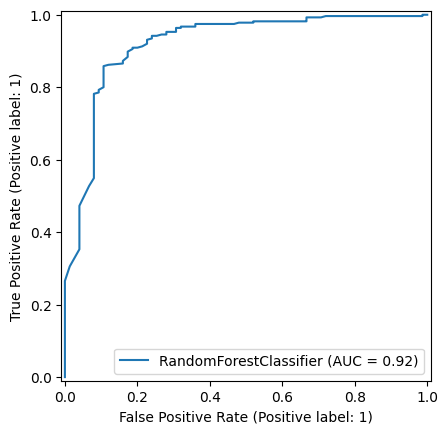

In [130]:
# Visualize ROC Curve
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(
    rf,
    X_test_final,
    y_test
)

plt.show()

The Random Forest classifier trained on Sentence-BERT embeddings was selected as the final model. It achieved an accuracy of 90.0%, precision of 91.1%, recall of 96.7%, and an F1-score of 93.8% on the test set. The model also obtained a ROC-AUC score of 0.92, demonstrating strong discriminative capability between urgent and non-urgent complaints. Five-fold cross-validation yielded a mean F1-score of 0.928 with low variability (standard deviation = 0.014), indicating stable performance across different data splits. Since the primary objective was to minimize false negatives and correctly identify urgent complaints, the high recall achieved by the model makes it suitable for complaint prioritization tasks.

In [131]:
# Check Important Error Cases
error_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': rf.predict(X_test_final)
})

error_df = error_df[error_df['Actual'] != error_df['Predicted']]

print("Total Errors:", len(error_df))
error_df.head(10)

Total Errors: 35


,Actual,Predicted
11,1,0
39,0,1
48,0,1
53,0,1
62,0,1
73,1,0
91,0,1
94,1,0
96,0,1
98,0,1


In [132]:
# False Negatives
test_pred = rf.predict(X_test_final)
fn_idx = (y_test == 1) & (test_pred == 0)

false_negatives = X_test.loc[fn_idx]

false_negatives.head()

,Product,Sentiment,num_of_words,trans_text
1555,"Money transfer, virtual currency, or money ser...",0,567,recent got phone previou employ well fargo hom...
1429,Loans,0,410,account speedi cash open loan daili interest p...
1216,"Credit reporting, repair, or other",0,495,public record entri place credit report tri th...
1740,Mortgage,1,267,2016 home sold unlaw sheriff sale foreclosur s...
508,Loans,0,396,cosign student loan call navient payoff amount...


Error analysis revealed that the majority of false negatives corresponded to lengthy complaint narratives in which urgency-related information was embedded within extensive contextual details. These complaints often lacked explicit urgency indicators, making them difficult to distinguish from non-urgent complaints. Despite these challenges, the model misclassified only 9 out of 275 urgent complaints, achieving a recall of 96.7%, which demonstrates its effectiveness in identifying high-priority cases.

In [133]:
# False Positives
fp_idx = (y_test == 0) & (test_pred == 1)

false_positives = X_test.loc[fp_idx]

false_positives.head()

,Product,Sentiment,num_of_words,trans_text
402,Debt collection,0,183,refus remov medic debt urgent care bill disput...
716,"Money transfer, virtual currency, or money ser...",0,334,paypal accept list bitcoin product sold websit...
897,Checking or savings account or service,0,380,chase bank littl year even though check clear ...
795,Mortgage,0,173,3 year ago move tri sell hous short sale realt...
728,"Money transfer, virtual currency, or money ser...",0,138,hello send money walmart use money gram intern...


Analysis of false positive cases revealed that many non-urgent complaints contained language commonly associated with urgent financial issues, such as debt disputes, mortgage problems, account-related concerns, and money transfer failures. Because Sentence-BERT captures semantic similarity, the model tended to assign higher urgency to complaints whose content closely resembled genuinely urgent cases. While this increased the number of false positives, it contributed to the model's ability to maintain a very high recall and minimize false negatives.

In [134]:
# Final Validation Table
final_validation = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Value":[
        accuracy_score(y_test,test_pred),
        precision_score(y_test,test_pred),
        recall_score(y_test,test_pred),
        f1_score(y_test,test_pred),
        roc_auc_score(y_test,prob)
    ]
})

final_validation

,Metric,Value
0,Accuracy,0.900000
1,Precision,0.910959
2,Recall,0.967273
3,F1 Score,0.938272
4,ROC-AUC,0.919612


Among all the feature representation techniques and classification algorithms evaluated, the combination of Sentence-BERT embeddings and Random Forest was selected as the final model. The model achieved an accuracy of 90.0%, precision of 91.1%, recall of 96.7%, F1-score of 93.8%, and ROC-AUC of 92.0%. The high recall indicates that the model successfully identified the majority of urgent complaints while minimizing false negatives. Although the model generated a slightly higher number of false positives, this trade-off is acceptable because the cost of missing an urgent complaint is substantially higher than incorrectly flagging a non-urgent complaint as urgent. Cross-validation results further demonstrated stable performance across different data splits, confirming the robustness and generalizability of the model.

In [137]:
# Prediction
prediction = rf.predict(X_test_final)
confidence = rf.predict_proba(X_test_final)

In [138]:
print(prediction)
print(confidence)

[1 1 0 1 1 1 1 1 1 0 1 0 1 1 1 1 0 1 1 0 1 0 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 0 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 0
 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1
 1 1 0 1 1 1 0 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 1
 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 0 0 1 0 1 1 1
 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1
 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 0
 1 1 0 1 1 0 0 1 1 1 1 1 1 1 1 1 1]
[[0.08  0.92 ]
 [0.07  0.93 ]
 [0.755 0.245]
 [0.085 0.915]
 [0.04  0.96 ]
 [0.09  0.91 ]
 [0.055 0.945]
 [0.05  0.95 ]
 [0.09  0.91 ]
 [0.71  0.29 ]
 [0.06  0.94 ]
 [0.66  0.34 ]
 [0.09  0.91 ]
 [0.22  0.78 ]
 [0.25  0.75 ]
 [0.065 0.935]
 [0.605 0.395]
 [0.08  0.92 ]
 [0.13  0.87 ]
 [0.

# ============================================
# AI FINANCIAL COMPLAINT ASSISTANT
# ============================================

In [139]:
import joblib

joblib.dump(rf, "best_rf.pkl")
joblib.dump(ohe, "product_encoder.pkl")

print("Saved Successfully")

Saved Successfully


## To make predict sentiment automatically

In [152]:
from transformers import pipeline

sentiment_pipeline = pipeline("sentiment-analysis")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

C:\Users\aishw\.conda\envs\finance\lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\aishw\.cache\huggingface\hub\models--distilbert--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

In [140]:
import joblib
import numpy as np
from sentence_transformers import SentenceTransformer

rf = joblib.load("best_rf.pkl")

ohe = joblib.load("product_encoder.pkl")

sbert = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [154]:
# user input
complaint = """
My debit card has been blocked.
I cannot withdraw money from the ATM.
"""

product = "Bank Account"

In [155]:
result = sentiment_pipeline(complaint)

print(result)

[{'label': 'NEGATIVE', 'score': 0.9944708347320557}]


In [156]:
label = result[0]["label"]

if label == "NEGATIVE":
    sentiment = -1
else: 
    sentiment = 0

In [157]:
# calculating no of words
num_of_words = len(complaint.split())

In [158]:
# generating sentence BERT embeddings
embedding = sbert.encode([complaint])

In [159]:
# encoding product
product_vector = ohe.transform([[product]])

C:\Users\aishw\.conda\envs\finance\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(
C:\Users\aishw\.conda\envs\finance\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [160]:
# numerical features
num_features = np.array([[sentiment, num_of_words]])

In [161]:
# final feature vector
X_new = np.hstack([
    embedding,
    product_vector,
    num_features
])

In [162]:
# Prediction
prediction = rf.predict(X_new)[0]

In [163]:
# confidence
confidence = rf.predict_proba(X_new)[0]

In [164]:
# Display
label = "Urgent" if prediction == 1 else "Not Urgent"

print("Prediction :", label)
print("Confidence :", confidence.max())

Prediction : Urgent
Confidence : 0.88



## GENERATIVE AI ASSISTANT


In [193]:
import sys

!{sys.executable} -m pip install -U google-genai

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.



   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ----------------------------- ---------- 0.8/1.1 MB 4.8 MB/s eta 0:00:01
   ----------------------------- ---------- 0.8/1.1 MB 4.8 MB/s eta 0:00:01
   ---------------------------------------- 1.1/1.1 MB 1.7 MB/s  0:00:00

   ---------------------------------------- 0/4 [tenacity]
   ---------------------------------------- 0/4 [tenacity]
   ---------------------------------------- 0/4 [tenacity]
   ---------- ----------------------------- 1/4 [sniffio]
   -------------------- ------------------- 2/4 [distro]
   ------------------------------ --------- 3/4 [google-genai]
   ------------------------------ --------- 3/4 [google-genai]
   ------------------------------ --------- 3/4 [google-genai]
   ------------------------------ --------- 3/4 [google-genai]
   ------------------------------ --------- 3/4 [google-genai]
   ------------------------------ --------- 3/4 [google-genai]
   ------------------------------ 

In [194]:
from google import genai

In [1]:
client = genai.Client(api_key="Enter your API KEY")

NameError: name 'genai' is not defined

### loading the gemini model

In [207]:
# creating the prompt
prompt = f"""
You are an AI Financial Complaint Assistant.

Customer Complaint:
{complaint}

Product:
{product}

Predicted Priority:
{label}

Your task is to generate the following sections.

Complaint Summary

Reason for the Predicted Priority

Suggested Department

Recommended Next Action

Professional Customer Reply

Rules:
- Use only the provided complaint.
- Do not invent any information.
- Use only the information explicitly provided in the complaint.
- Do not infer financial loss, fraud, or emotional impact unless mentioned.
- If information is missing, do not assume it.
- Keep the summary under 2 sentences.
- Keep the summary concise.
- Keep the explanation professional.
- Do NOT write introductory sentences such as
  "Based on the provided complaint..."
- Directly start with the required headings.
"""

In [208]:
# sending the prompt to Gemini
response = client.models.generate_content(
    model="gemini-3.5-flash",
    contents=prompt
)

In [209]:
print(response.text)

Complaint Summary
The customer's debit card is blocked. As a result, they cannot withdraw money from the ATM.

Reason for the Predicted Priority
The priority is urgent because the customer's debit card is blocked, completely restricting their ability to perform ATM withdrawals.

Suggested Department
Debit Card Services

Recommended Next Action
Verify the status of the customer's debit card and investigate the reason for the ATM withdrawal restriction.

Professional Customer Reply
Dear Customer,

We have received your complaint stating that your debit card is blocked and you cannot withdraw money from the ATM. We are currently investigating the status of your bank account's debit card to resolve this matter.
